# TPC$_{RP}$ Active Learning — CIFAR-10

Implementation of the **TypiClust (TPC$_{RP}$)** algorithm from:
> Hacohen, G., Dekel, A., & Weinshall, D. (2022). *Active Learning on a Budget: Opposite Strategies Suit High and Low Budgets.* ICML 2022.

**Strategy:** Self-supervised representation learning (simulated via pre-trained ResNet-18)  
→ K-Means clustering for diversity  
→ Typicality-based selection within each cluster.

In [1]:
# ── Cell 1: Setup & Imports ──────────────────────────────────────────────────

# Mount Google Drive and add src/ to path when running on Colab
import sys, os

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_ROOT = '/content/drive/MyDrive/MachineLearning-Coursework2'
    sys.path.insert(0, os.path.join(REPO_ROOT, 'src'))
else:
    # Local: repo root is one level above notebooks/
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    sys.path.insert(0, os.path.join(REPO_ROOT, 'src'))

# Standard library
import random
import warnings
warnings.filterwarnings('ignore')

# Numerical & ML
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# Clustering & neighbours
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

# Visualisation
import matplotlib
import matplotlib.pyplot as plt

# Project modules
from data_pipeline     import ActiveLearningDataset
from feature_extractor import ResNet18FeatureExtractor, extract_embeddings, build_extractor
from tpcrp_sampler     import tpcrp_query

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = (
    torch.device('cuda')  if torch.cuda.is_available() else
    torch.device('mps')   if torch.backends.mps.is_available() else
    torch.device('cpu')
)
print(f'Using device: {DEVICE}')
print(f'PyTorch {torch.__version__} | Torchvision {torchvision.__version__}')

Using device: mps
PyTorch 2.11.0 | Torchvision 0.26.0


In [2]:
# ── Cell 2: Data Pipeline ────────────────────────────────────────────────────

DATA_ROOT = os.path.join(REPO_ROOT, 'data')

al_dataset = ActiveLearningDataset(root=DATA_ROOT, download=True)
print(al_dataset)
print(f'Classes : {al_dataset.classes}')
print(f'Train   : {len(al_dataset.full_dataset):,} examples')
print(f'Test    : {len(al_dataset.test_dataset):,} examples')

ActiveLearningDataset(CIFAR-10 | labeled=0, unlabeled=50000)
Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train   : 50,000 examples
Test    : 10,000 examples


In [3]:
# ── Cell 3: Feature Extraction ───────────────────────────────────────────────
#
# Extract L2-normalised 512-D embeddings from a pre-trained ResNet-18
# for the entire training set.  These are computed once and reused
# across all active learning iterations.

model, device = build_extractor(pretrained=True, device=DEVICE)

# Use the full (unlabeled) training set for embedding extraction.
# We create a temporary loader directly from the full dataset so that
# the index positions in all_embeddings align with the dataset indices.
full_loader = al_dataset.get_unlabeled_loader(batch_size=256, shuffle=False)

print('Extracting embeddings for the full training set...')
all_embeddings, all_labels = extract_embeddings(model, full_loader, device)

print(f'Embeddings shape : {all_embeddings.shape}')   # (50000, 512)
print(f'Labels shape     : {all_labels.shape}')       # (50000,)
print(f'Embedding norms  : min={np.linalg.norm(all_embeddings, axis=1).min():.4f}',
      f'max={np.linalg.norm(all_embeddings, axis=1).max():.4f}')  # should be ~1.0

Extracting embeddings for the full training set...
Embeddings shape : (50000, 512)
Labels shape     : (50000,)
Embedding norms  : min=1.0000 max=1.0000


In [4]:
# ── Cell 3b: Test-Set Embedding Extraction ───────────────────────────────────
#
# Extract L2-normalised embeddings for the full CIFAR-10 test set once.
# These are fixed across all AL iterations and are used by the linear probe.

from evaluator import evaluate_linear_probe

test_loader = al_dataset.get_test_loader(batch_size=256)

print('Extracting embeddings for the test set...')
test_embeddings, test_labels = extract_embeddings(model, test_loader, device)

print(f'Test embeddings shape : {test_embeddings.shape}')   # (10000, 512)
print(f'Test labels shape     : {test_labels.shape}')       # (10000,)
print(f'Embedding norms       : min={np.linalg.norm(test_embeddings, axis=1).min():.4f}',
      f'max={np.linalg.norm(test_embeddings, axis=1).max():.4f}')  # should be ~1.0

Extracting embeddings for the test set...
Test embeddings shape : (10000, 512)
Test labels shape     : (10000,)
Embedding norms       : min=1.0000 max=1.0000


In [5]:
# ── Cell 4: TPC_RP Active Learning Loop (dry run) ───────────────────────────
#
# Ties together Dataset ▸ Feature Extractor ▸ TPC_RP Sampler.
# We run 5 iterations with a per-round budget of B=10 (one per class)
# and simply print the selected indices to verify the pipeline works.
# No downstream classifier is trained here.

N_ITERATIONS = 5
BUDGET       = 10   # B = number of classes in CIFAR-10

# Fresh start — all examples unlabeled
al_dataset.reset()

print('=' * 60)
print(f'TPC_RP dry run  |  {N_ITERATIONS} iterations  |  B={BUDGET} per round')
print('=' * 60)

for iteration in range(1, N_ITERATIONS + 1):

    # ── Run TPC_RP sampler ──────────────────────────────────────────────────
    queried_indices = tpcrp_query(
        all_features      = all_embeddings,
        unlabeled_indices = al_dataset.unlabeled_indices,
        labeled_indices   = al_dataset.labeled_indices,
        budget            = BUDGET,
        seed              = SEED + iteration,
    )

    # ── Move queried indices to the labeled pool ────────────────────────────
    al_dataset.query_samples(queried_indices)

    # ── Retrieve ground-truth classes for inspection ────────────────────────
    queried_classes = [al_dataset.full_dataset.targets[i] for i in queried_indices]
    class_names     = [al_dataset.classes[c] for c in queried_classes]

    # ── Report ──────────────────────────────────────────────────────────────
    cumulative_budget = al_dataset.num_labeled
    print(f'\nIteration {iteration}')
    print(f'  Queried indices  : {queried_indices}')
    print(f'  Classes selected : {class_names}')
    print(f'  Unique classes   : {len(set(queried_classes))} / {BUDGET}')
    print(f'  Cumulative budget: {cumulative_budget} labeled  |  '
          f'{al_dataset.num_unlabeled} unlabeled')

print('\n' + '=' * 60)
print('Dry run complete.  Pipeline verified.')
print(f'Total labeled after {N_ITERATIONS} rounds: {al_dataset.num_labeled}')

TPC_RP dry run  |  5 iterations  |  B=10 per round

Iteration 1
  Queried indices  : [22073, 40636, 12071, 45093, 11968, 29627, 20802, 44273, 27315, 34173]
  Classes selected : ['dog', 'ship', 'automobile', 'truck', 'frog', 'frog', 'frog', 'automobile', 'airplane', 'airplane']
  Unique classes   : 6 / 10
  Cumulative budget: 10 labeled  |  49990 unlabeled

Iteration 2
  Queried indices  : [26647, 17586, 43225, 22022, 29054, 23582, 23304, 32058, 14184, 39387]
  Classes selected : ['truck', 'automobile', 'dog', 'ship', 'truck', 'frog', 'horse', 'airplane', 'dog', 'automobile']
  Unique classes   : 7 / 10
  Cumulative budget: 20 labeled  |  49980 unlabeled

Iteration 3
  Queried indices  : [7918, 15988, 25909, 38998, 22179, 22715, 18354, 14510, 25043, 22311]
  Classes selected : ['frog', 'automobile', 'automobile', 'truck', 'horse', 'dog', 'automobile', 'truck', 'horse', 'truck']
  Unique classes   : 5 / 10
  Cumulative budget: 30 labeled  |  49970 unlabeled

Iteration 4
  Queried indices

In [6]:
# ── Cell 5: TPC_RP Active Learning Loop — Linear Probe Evaluation ────────────
#
# Runs the full AL loop (10 iterations, B=10 per round → 10 to 100 labels).
# After each query, fits a logistic regression probe on the labeled embeddings
# and records test accuracy, following Section 4.2.2 of Hacohen et al. (2022).

BUDGET       = 10    # B = number of CIFAR-10 classes
N_ITERATIONS = 10    # cumulative budget: 10 → 100 labeled examples

# Fresh start
al_dataset.reset()

tpcrp_accuracies: list[float] = []
tpcrp_budgets:    list[int]   = []

print('=' * 65)
print(f' TPC_RP  |  {N_ITERATIONS} iterations  |  B={BUDGET}  |  Linear Probe Eval')
print('=' * 65)
print(f'{"Iter":>4}  {"Labeled":>7}  {"Test Acc":>9}')
print('-' * 65)

for iteration in range(1, N_ITERATIONS + 1):

    # ── 1. Query with TPC_RP ─────────────────────────────────────────────────
    queried_indices = tpcrp_query(
        all_features      = all_embeddings,
        unlabeled_indices = al_dataset.unlabeled_indices,
        labeled_indices   = al_dataset.labeled_indices,
        budget            = BUDGET,
        seed              = SEED + iteration,
    )
    al_dataset.query_samples(queried_indices)

    # ── 2. Slice current labeled embeddings ──────────────────────────────────
    labeled_idx     = np.array(al_dataset.labeled_indices)
    train_features  = all_embeddings[labeled_idx]
    train_labels_np = all_labels[labeled_idx]

    # ── 3. Linear probe evaluation ───────────────────────────────────────────
    acc = evaluate_linear_probe(
        train_features = train_features,
        train_labels   = train_labels_np,
        test_features  = test_embeddings,
        test_labels    = test_labels,
        seed           = SEED,
    )

    tpcrp_accuracies.append(acc)
    tpcrp_budgets.append(al_dataset.num_labeled)

    print(f'{iteration:>4}  {al_dataset.num_labeled:>7}  {acc:>8.2%}')

print('=' * 65)
print(f'Final accuracy at {al_dataset.num_labeled} labels: {tpcrp_accuracies[-1]:.2%}')

 TPC_RP  |  10 iterations  |  B=10  |  Linear Probe Eval
Iter  Labeled   Test Acc
-----------------------------------------------------------------
   1       10    17.46%
   2       20    25.05%
   3       30    22.69%
   4       40    25.88%
   5       50    27.49%
   6       60    27.42%
   7       70    29.95%
   8       80    28.55%
   9       90    30.38%
  10      100    30.84%
Final accuracy at 100 labels: 30.84%


Plot saved → /Users/josepires/Documents/ML_COURSEWORK_2/MachineLearning-Coursework2/figures/tpcrp_baseline_curve.png


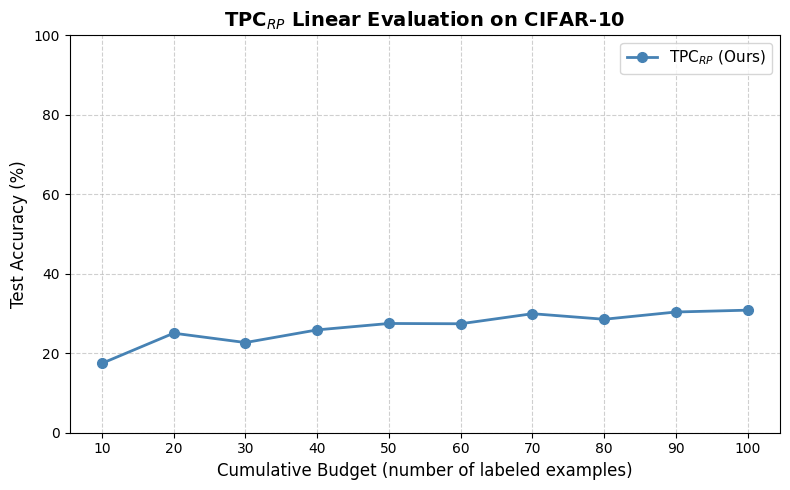

In [7]:
# ── Cell 6: Learning Curve Plot ──────────────────────────────────────────────

FIGURES_DIR = os.path.join(REPO_ROOT, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    tpcrp_budgets,
    [a * 100 for a in tpcrp_accuracies],
    marker='o',
    linewidth=2,
    markersize=7,
    color='steelblue',
    label=r'TPC$_{RP}$ (Ours)',
)

# Formatting
ax.set_title(r'TPC$_{RP}$ Linear Evaluation on CIFAR-10', fontsize=14, fontweight='bold')
ax.set_xlabel('Cumulative Budget (number of labeled examples)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_xticks(tpcrp_budgets)
ax.set_ylim(0, 100)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)

fig.tight_layout()

save_path = os.path.join(FIGURES_DIR, 'tpcrp_baseline_curve.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Plot saved → {save_path}')
plt.show()

In [8]:
# ── Cell 7: Multi-Seed Statistical Comparison — TPC_RP vs Random ─────────────
#
# Runs both strategies across 5 seeds (42–46) for 10 iterations × B=10.
# Produces accuracy matrices of shape (n_seeds, n_iterations) for each method,
# then performs a paired t-test on the final-budget (B=100) accuracies.

from scipy import stats
from tpcrp_sampler import random_query

SEEDS        = [42, 43, 44, 45, 46]
BUDGET       = 10
N_ITERATIONS = 10
BUDGETS_AXIS = list(range(BUDGET, BUDGET * N_ITERATIONS + 1, BUDGET))  # [10..100]

tpcrp_matrix = np.zeros((len(SEEDS), N_ITERATIONS))   # (5, 10)
random_matrix = np.zeros((len(SEEDS), N_ITERATIONS))  # (5, 10)

for s_idx, seed in enumerate(SEEDS):
    print(f'\n── Seed {seed} ──────────────────────────────────────')

    # ── TPC_RP ───────────────────────────────────────────────────────────────
    al_dataset.reset()
    for it in range(N_ITERATIONS):
        queried = tpcrp_query(
            all_features      = all_embeddings,
            unlabeled_indices = al_dataset.unlabeled_indices,
            labeled_indices   = al_dataset.labeled_indices,
            budget            = BUDGET,
            seed              = seed + it,
        )
        al_dataset.query_samples(queried)
        idx = np.array(al_dataset.labeled_indices)
        acc = evaluate_linear_probe(all_embeddings[idx], all_labels[idx],
                                    test_embeddings, test_labels, seed=seed)
        tpcrp_matrix[s_idx, it] = acc

    # ── Random ───────────────────────────────────────────────────────────────
    al_dataset.reset()
    for it in range(N_ITERATIONS):
        queried = random_query(
            unlabeled_indices = al_dataset.unlabeled_indices,
            budget            = BUDGET,
            seed              = seed + it,
        )
        al_dataset.query_samples(queried)
        idx = np.array(al_dataset.labeled_indices)
        acc = evaluate_linear_probe(all_embeddings[idx], all_labels[idx],
                                    test_embeddings, test_labels, seed=seed)
        random_matrix[s_idx, it] = acc

    print(f'  TPC_RP  final acc: {tpcrp_matrix[s_idx, -1]:.2%}')
    print(f'  Random  final acc: {random_matrix[s_idx, -1]:.2%}')

# ── Summary statistics ────────────────────────────────────────────────────────
tpcrp_mean  = tpcrp_matrix.mean(axis=0) * 100   # (10,) in %
tpcrp_std   = tpcrp_matrix.std(axis=0)  * 100
random_mean = random_matrix.mean(axis=0) * 100
random_std  = random_matrix.std(axis=0)  * 100

final_tpcrp  = tpcrp_matrix[:, -1]   # shape (5,) at B=100
final_random = random_matrix[:, -1]

t_stat, p_value = stats.ttest_rel(final_tpcrp, final_random)

print('\n' + '=' * 60)
print('Statistical Summary at B=100')
print('=' * 60)
print(f'TPC_RP : {final_tpcrp.mean()*100:.2f}% ± {final_tpcrp.std()*100:.2f}%')
print(f'Random : {final_random.mean()*100:.2f}% ± {final_random.std()*100:.2f}%')
print(f't-statistic : {t_stat:.4f}')
print(f'p-value     : {p_value:.4f}')
print(f'Significant : {"YES (p < 0.05)" if p_value < 0.05 else "NO (p >= 0.05)"}')


── Seed 42 ──────────────────────────────────────
  TPC_RP  final acc: 30.83%
  Random  final acc: 37.58%

── Seed 43 ──────────────────────────────────────
  TPC_RP  final acc: 31.58%
  Random  final acc: 32.98%

── Seed 44 ──────────────────────────────────────
  TPC_RP  final acc: 32.26%
  Random  final acc: 32.04%

── Seed 45 ──────────────────────────────────────
  TPC_RP  final acc: 28.16%
  Random  final acc: 32.70%

── Seed 46 ──────────────────────────────────────
  TPC_RP  final acc: 31.04%
  Random  final acc: 33.29%

Statistical Summary at B=100
TPC_RP : 30.77% ± 1.40%
Random : 33.72% ± 1.97%
t-statistic : -2.4074
p-value     : 0.0738
Significant : NO (p >= 0.05)


Plot saved → /Users/josepires/Documents/ML_COURSEWORK_2/MachineLearning-Coursework2/figures/statistical_comparison.png


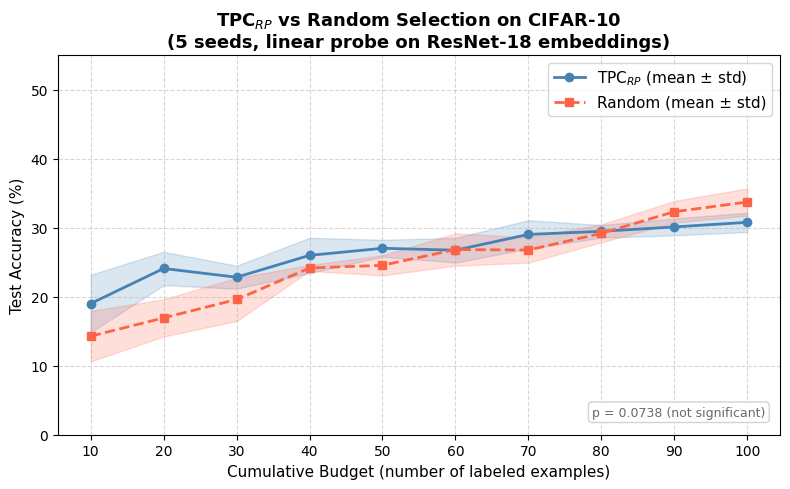

In [9]:
# ── Cell 8: Statistical Comparison Plot (mean ± std) ─────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

# TPC_RP curve
ax.plot(BUDGETS_AXIS, tpcrp_mean, marker='o', linewidth=2, markersize=6,
        color='steelblue', label=r'TPC$_{RP}$ (mean ± std)')
ax.fill_between(BUDGETS_AXIS,
                tpcrp_mean - tpcrp_std,
                tpcrp_mean + tpcrp_std,
                color='steelblue', alpha=0.2)

# Random baseline curve
ax.plot(BUDGETS_AXIS, random_mean, marker='s', linewidth=2, markersize=6,
        color='tomato', linestyle='--', label='Random (mean ± std)')
ax.fill_between(BUDGETS_AXIS,
                random_mean - random_std,
                random_mean + random_std,
                color='tomato', alpha=0.2)

# Formatting
ax.set_title(r'TPC$_{RP}$ vs Random Selection on CIFAR-10'
             '\n(5 seeds, linear probe on ResNet-18 embeddings)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cumulative Budget (number of labeled examples)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_xticks(BUDGETS_AXIS)
ax.set_ylim(0, 55)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=11)

# Annotate p-value
sig_text = f'p = {p_value:.4f} ({"significant" if p_value < 0.05 else "not significant"})'
ax.annotate(sig_text, xy=(0.98, 0.05), xycoords='axes fraction',
            ha='right', fontsize=9, color='dimgray',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgray'))

fig.tight_layout()

save_path = os.path.join(FIGURES_DIR, 'statistical_comparison.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Plot saved → {save_path}')
plt.show()

In [10]:
# ── Cell 9: DynTPC Multi-Seed Evaluation ─────────────────────────────────────
#
# Runs Dynamic Phase-Shift TypiClust (DynTPC) across 5 seeds.
# Sampling switches from argmax → argmin typicality at phase_threshold=60
# labeled examples, aligned with the paper's predicted phase transition.

from tpcrp_sampler import dynamic_tpcrp_query

PHASE_THRESHOLD = 60   # flip point: 6 rounds × B=10

dyntpc_matrix = np.zeros((len(SEEDS), N_ITERATIONS))  # (5, 10)

for s_idx, seed in enumerate(SEEDS):
    print(f'\n── Seed {seed} ──────────────────────────────────────')
    al_dataset.reset()

    for it in range(N_ITERATIONS):
        queried = dynamic_tpcrp_query(
            all_features      = all_embeddings,
            unlabeled_indices = al_dataset.unlabeled_indices,
            labeled_indices   = al_dataset.labeled_indices,
            budget            = BUDGET,
            phase_threshold   = PHASE_THRESHOLD,
            seed              = seed + it,
        )
        al_dataset.query_samples(queried)

        idx = np.array(al_dataset.labeled_indices)
        acc = evaluate_linear_probe(all_embeddings[idx], all_labels[idx],
                                    test_embeddings, test_labels, seed=seed)
        dyntpc_matrix[s_idx, it] = acc

        mode = 'TYPICAL (argmax)' if al_dataset.num_labeled - BUDGET < PHASE_THRESHOLD \
               else 'ATYPICAL (argmin)'
        print(f'  iter {it+1:>2} | B={al_dataset.num_labeled:>3} | {mode} | acc={acc:.2%}')

dyntpc_mean = dyntpc_matrix.mean(axis=0) * 100
dyntpc_std  = dyntpc_matrix.std(axis=0)  * 100

print('\n' + '=' * 60)
print(f'DynTPC final accuracy at B=100: '
      f'{dyntpc_matrix[:,-1].mean()*100:.2f}% ± {dyntpc_matrix[:,-1].std()*100:.2f}%')


── Seed 42 ──────────────────────────────────────
  iter  1 | B= 10 | TYPICAL (argmax) | acc=17.46%
  iter  2 | B= 20 | TYPICAL (argmax) | acc=23.93%
  iter  3 | B= 30 | TYPICAL (argmax) | acc=23.81%
  iter  4 | B= 40 | TYPICAL (argmax) | acc=27.43%
  iter  5 | B= 50 | TYPICAL (argmax) | acc=28.78%
  iter  6 | B= 60 | TYPICAL (argmax) | acc=28.24%
  iter  7 | B= 70 | ATYPICAL (argmin) | acc=28.21%
  iter  8 | B= 80 | ATYPICAL (argmin) | acc=28.78%
  iter  9 | B= 90 | ATYPICAL (argmin) | acc=30.01%
  iter 10 | B=100 | ATYPICAL (argmin) | acc=32.03%

── Seed 43 ──────────────────────────────────────
  iter  1 | B= 10 | TYPICAL (argmax) | acc=17.46%
  iter  2 | B= 20 | TYPICAL (argmax) | acc=25.05%
  iter  3 | B= 30 | TYPICAL (argmax) | acc=22.69%
  iter  4 | B= 40 | TYPICAL (argmax) | acc=26.03%
  iter  5 | B= 50 | TYPICAL (argmax) | acc=27.49%
  iter  6 | B= 60 | TYPICAL (argmax) | acc=27.42%
  iter  7 | B= 70 | ATYPICAL (argmin) | acc=28.24%
  iter  8 | B= 80 | ATYPICAL (argmin) | acc

Plot saved → /Users/josepires/Documents/ML_COURSEWORK_2/MachineLearning-Coursework2/figures/dyntpc_comparison.png


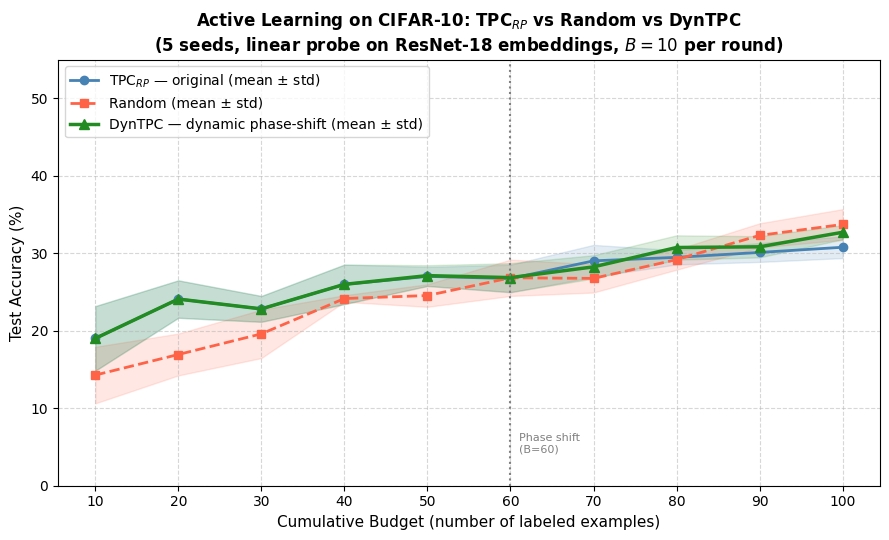

In [11]:
# ── Cell 10: Grand Finale — Three-Way Comparison Plot ────────────────────────

fig, ax = plt.subplots(figsize=(9, 5.5))

# TPC_RP
ax.plot(BUDGETS_AXIS, tpcrp_mean, marker='o', linewidth=2, markersize=6,
        color='steelblue', label=r'TPC$_{RP}$ — original (mean ± std)')
ax.fill_between(BUDGETS_AXIS, tpcrp_mean - tpcrp_std, tpcrp_mean + tpcrp_std,
                color='steelblue', alpha=0.15)

# Random baseline
ax.plot(BUDGETS_AXIS, random_mean, marker='s', linewidth=2, markersize=6,
        color='tomato', linestyle='--', label='Random (mean ± std)')
ax.fill_between(BUDGETS_AXIS, random_mean - random_std, random_mean + random_std,
                color='tomato', alpha=0.15)

# DynTPC
ax.plot(BUDGETS_AXIS, dyntpc_mean, marker='^', linewidth=2.5, markersize=7,
        color='forestgreen', label=r'DynTPC — dynamic phase-shift (mean ± std)')
ax.fill_between(BUDGETS_AXIS, dyntpc_mean - dyntpc_std, dyntpc_mean + dyntpc_std,
                color='forestgreen', alpha=0.15)

# Phase-transition marker
ax.axvline(x=PHASE_THRESHOLD, color='grey', linestyle=':', linewidth=1.5)
ax.text(PHASE_THRESHOLD + 1, 4, f'Phase shift\n(B={PHASE_THRESHOLD})',
        fontsize=8, color='grey', va='bottom')

# Formatting
ax.set_title('Active Learning on CIFAR-10: TPC$_{RP}$ vs Random vs DynTPC\n'
             r'(5 seeds, linear probe on ResNet-18 embeddings, $B=10$ per round)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cumulative Budget (number of labeled examples)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_xticks(BUDGETS_AXIS)
ax.set_ylim(0, 55)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=10, loc='upper left')

fig.tight_layout()

save_path = os.path.join(FIGURES_DIR, 'dyntpc_comparison.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Plot saved → {save_path}')
plt.show()